#Algoritmos de ensemble


É um algoritmo de ensemble (combinação de muitos modelos). Ensemble pode ocorrer de duas formas:

1. Bagging– Cria um subconjunto de treinamento diferente dos dados de treinamento. Encontra modelos diferentes. A resposta do target final é baseada na votação por maioria. Por exemplo, Random Forest.

2. Boosting – Combina modelos fracos e modelos fortes, criando modelos sequenciais de modo que o modelo final tenha a maior precisão. Por exemplo, ADA BOOST, XG BOOST
Também baseado em árvore se decisão, um algoritmo de boosting ao invés de bagging.


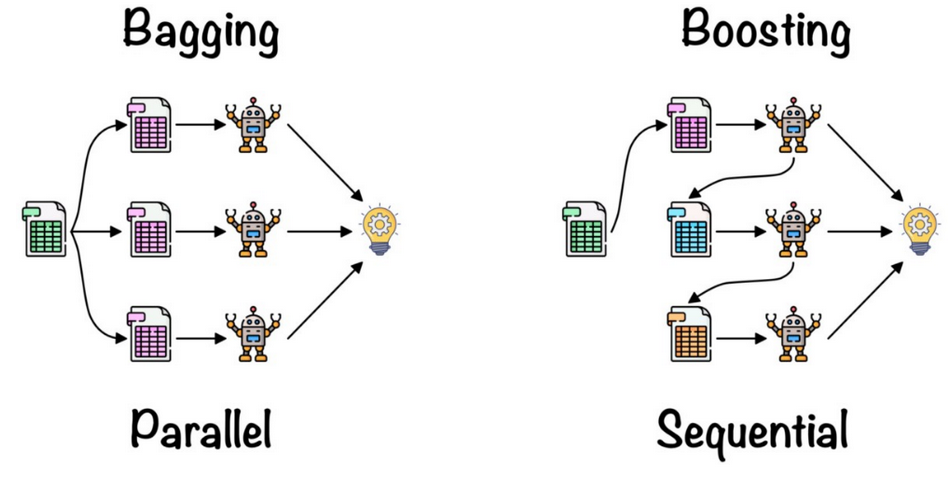

#XGBoost (eXtreme Gradient Boosting)

É uma biblioteca de aprendizado de máquina que implementa o algoritmo de Gradient Boosting, um método de aprendizado supervisionado amplamente utilizado em problemas de classificação e regressão de dados estruturados/tabulares. Ele se destaca por sua eficiência, escalabilidade e desempenho.

O Gradient Boosting cria um modelo preditivo combinando vários modelos fracos (normalmente árvores de decisão).
O processo é iterativo:
1. Inicializa com um modelo simples (uma árvore ou um valor constante para regressão).
2. Calcula o erro residual: a diferença entre o valor predito pelo modelo atual e o valor real.
3. Treina uma nova árvore para prever os erros residuais.
4. Combina os modelos: os modelos subsequentes que corrigem os erros dos anteriores.

Esse processo continua por várias iterações, ajustando os modelos para um preditor mais preciso.


Artigo de 2016 de sua criação: [link](https://arxiv.org/pdf/1603.02754)

GitHub do projeto público: [link](https://arxiv.org/pdf/1603.02754)

Desde a sua introdução, este algoritmo tem sido o mais vitorioso no Kaggle.

In [1]:
import numpy as np
#import matplotlib.pyplot as plt
#from matplotlib.colors import ListedColormap
import pandas as pd
import seaborn as sns

#from sklearn import tree

#from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
#from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#from sklearn.linear_model import LinearRegression
#from sklearn.tree import DecisionTreeRegressor
#from sklearn.ensemble import RandomForestRegressor

#from sklearn.tree import DecisionTreeClassifier
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor

#from sklearn.svm import SVC
from sklearn.svm import SVR

#from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

#from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

#from sklearn.metrics import accuracy_score
#from sklearn.metrics import confusion_matrix
#from sklearn.metrics import plot_confusion_matrix


In [2]:
path = 'https://raw.githubusercontent.com/OrlandoIFPR/ml2/refs/heads/main/Dataframes/'

In [3]:
dataset = pd.read_csv(path+ 'melb_data.csv')

dataset.head()

,Unnamed: 0,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,5,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,6,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [4]:
dataset = dataset.dropna(axis=0) #retira as linhas com NaN
features = ['Rooms', 'Bathroom', 'Landsize', 'Distance', 'BuildingArea', 'Car', 'YearBuilt','Postcode']

X = dataset[features]
y = dataset.Price

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

In [5]:
X_train

,Rooms,Bathroom,Landsize,Distance,BuildingArea,Car,YearBuilt,Postcode
14406,3,2.0,251.0,22.2,185.00,2.0,1998.0,3172.0
12944,2,2.0,0.0,7.9,101.76,1.0,2007.0,3103.0
11885,2,1.0,1646.0,1.9,52.00,1.0,2012.0,3205.0
10022,3,1.0,663.0,13.0,84.00,2.0,1950.0,3046.0
6949,2,2.0,0.0,2.6,70.00,1.0,2004.0,3121.0
...,...,...,...,...,...,...,...,...
12136,3,1.0,118.0,1.3,177.00,0.0,1890.0,3002.0
7694,5,2.0,661.0,13.3,133.00,2.0,1960.0,3020.0
3783,4,2.0,453.0,13.6,213.00,2.0,2007.0,3043.0
6034,2,1.0,90.0,3.8,106.00,1.0,2007.0,3207.0


In [6]:

sc = StandardScaler()
X_train = sc.fit_transform(X_train) #faz fit e transforma nos dados de treino
X_test = sc.transform(X_test) #nunca usar dados de teste para fazer fit! usar o mesmo scaler para escalar os dados de teste.

In [7]:
X_train

array([[ 0.05696508,  0.59226026, -0.230642  , ...,  0.47559647,
         0.90587495,  0.76702002],
       [-0.96592964,  0.59226026, -0.47810456, ..., -0.61381751,
         1.15116618,  0.0035045 ],
       [-0.96592964, -0.81674601,  1.14469776, ..., -0.61381751,
         1.28743908,  1.13217961],
       ...,
       [ 1.07985981,  0.59226026, -0.03148886, ...,  0.47559647,
         1.15116618, -0.66042203],
       [-0.96592964, -0.81674601, -0.38937296, ..., -0.61381751,
         1.15116618,  1.1543105 ],
       [ 0.05696508, -0.81674601,  0.00991922, ...,  0.47559647,
        -0.40234492, -0.33952421]])

In [8]:
from xgboost import XGBRegressor
regressor = XGBRegressor()
regressor.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

https://xgboost.readthedocs.io/en/stable/python/python_api.html

In [9]:
y_pred = regressor.predict(X_test)
mae=mean_absolute_error(y_test, y_pred)
mae

178863.16909184415

In [10]:
mae/y.mean()

0.16734510630065189